In [1]:
import sys
subdirs_git = "/Users/usuario/git/sisepuede"
path_git = pathlib.Path("/Users/usuario/git")

for subdir in [
    "sisepuede",
    "sisepuede_data_pipeline"
]:
    path_cur = str(path_git.joinpath(subdir))
    if path_cur not in sys.path:
        sys.path.append(path_cur)


import importlib
import matplotlib.pyplot as plt
import numpy as np
import os, os.path
import pandas as pd
import pathlib
import sisepuede.core.support_classes as sc
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.utilities.data_support._elasticities as elast
import sisepuede.utilities._toolbox as sf
import utils.common_data_needs as cdn
import warnings
warnings.filterwarnings("ignore")

from typing import *

plt.style.use("dark_background", )



/Users/usuario/git/sisepuede/sisepuede/utilities/_toolbox.py:533: UserWarning: Path '/Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2025-09-27T09;21;23.187614' not found. It will not be created.
  warnings.warn(msg)
/Users/usuario/git/sisepuede/sisepuede/core/model_attributes.py:6827: UserWarning: 

                        MISSIONSEARCHNOTE: As of 2023-10-06, there is a temporary solution 
                        implemeted in ModelAttributes.get_variable_to_simplex_group_dictionary() 
                        to ensure that transition probability rows are enforced on a simplex.
                        
                        
                        FIX THIS ASAP TO DERIVE PROPERLY.
                        
                        
  warnings.warn(
/Users/usuario/git/sisepuede/sisepuede/utilities/_toolbox.py:533: UserWarning: Path '/Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2025-09-27T09;21;23.564187' not found. It will not be created.
  warnings.warn(msg)
/Use

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1358.9 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
/Users/usuario/git/sisepuede/sisepuede/utilities/_toolbox.py:2622: UserWarning: Warning passed from optional_log: Successfully initialized JuMP optimizer from solver module HiGHS..
  warnings.warn(f"Warning passed from optional_log: {msg}.")


# Initialize some SISEPUEDE components

NameError: name 'ssp' is not defined

In [2]:
dict_ssp = cdn._setup_sisepuede_elements()

matt = dict_ssp.get("model_attributes", )
models = dict_ssp.get("models", )
regions = dict_ssp.get("regions", )
time_periods = dict_ssp.get("time_periods", )

# setup region
_REGION_NAME = "uganda"
_REGION_ISO = regions.return_region_or_iso(_REGION_NAME, return_type = "iso")

# set year of survey data
_YEAR_SURVEY = 2021
_YEAR_TARGET = 2100
_DF_YEARS = cdn.spawn_years_space_df((2015, _YEAR_TARGET + 1))


#############################
#    SOME INITIALIZATIONS   #
#############################

_ATTR_LNDU = matt.get_attribute_table(matt.subsec_name_lndu, )


##  Set some model variables

In [6]:
_MODVAR_AREA_TOTAL = matt.get_variable(models.model_afolu.model_socioeconomic.modvar_gnrl_area, )
_MODVAR_AREA_LNDU = matt.get_variable(models.model_afolu.modvar_lndu_area_by_cat, )
_MODVAR_AREA_FRAC_INIT = matt.get_variable(models.model_afolu.modvar_lndu_initial_frac, )
_MODVAR_LNDU_TRANSITION = matt.get_variable(models.model_afolu.modvar_lndu_prob_transition, )





In [281]:


build_new_shrublands_to_fsts_vec(df_inputs, )

array([0.0007828 , 0.07827983, 0.33      , 0.33      , 0.00782798])

##  Set some manual adjustment functions

In [400]:
def adjust_transitions_croplands_to_secondary(
    df_input: pd.DataFrame,
) -> pd.DataFrame:
    """Mangroves are not in Uganda. This removes any transitions into 
        mangroves, assigning those transitions back onto the diagonal.
        Option to specify some fraction into wetlands instead.
    """

    cat_src = "croplands"
    cat_targ = "forests_secondary"

    # set some fields
    field_src = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": [cat_src],
            "cat_landuse_dim2": [cat_src]
        }
    )[0]

    field_targ = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": [cat_src],
            "cat_landuse_dim2": [cat_targ]
        }
    )[0]
        
    val = max(df_input[field_targ].iloc[0], 0.0001)
    vec_orig = df_input[field_targ].to_numpy().copy()
    vec_new = vec_orig.copy()
    vec_new[vec_new == 0] = val

    diff = vec_new - vec_orig
    
    df_input[field_targ] = vec_new
    df_input[field_src] -= diff

    return df_input




def adjust_transitions_mangroves_inflow(
    df_input: pd.DataFrame,
    factor_remaining_into_wetlands: float = 0.0,
) -> pd.DataFrame:
    """Mangroves are not in Uganda. This removes any transitions into 
        mangroves, assigning those transitions back onto the diagonal.
        Option to specify some fraction into wetlands instead.
    """

    for cat in _ATTR_LNDU.key_values:
        field_src = _MODVAR_LNDU_TRANSITION.build_fields(
            category_restrictions = {
                "cat_landuse_dim1": [cat],
                "cat_landuse_dim2": ["forests_mangroves"]
            }
        )[0]

        field_targ = _MODVAR_LNDU_TRANSITION.build_fields(
            category_restrictions = {
                "cat_landuse_dim1": [cat],
                "cat_landuse_dim2": [cat]
            }
        )[0]
        #field_src = f"pij_lndu_{cat}_to_forests_mangroves"
        #field_targ = f"pij_lndu_{cat}_to_{cat}"
        
        vec_shift = (1 - factor_remaining_into_wetlands)*df_input[field_src].values
    
        df_input[field_targ] += vec_shift
        df_input[field_src] -= vec_shift

    return df_input



def adjust_transitions_other_inflow(
    df_input: pd.DataFrame,
    base_inflow: float = 0.00001,
) -> pd.DataFrame:
    """Other is very small, but growing. Can allow some classes to inflow.
        
        *   There are some manual adjustments first to remove "kinks" in 
            2016 and 2018
        *   There's a small amount of inflation applied to the transitions 
            in

    """
    cats_src = ["forests_secondary", "grasslands", "pastures", "shrublands", "wetlands"]
    cat_targ = "other"

    # apply to each category
    for cat in cats_src:
        field_src = _MODVAR_LNDU_TRANSITION.build_fields(
            category_restrictions = {
                "cat_landuse_dim1": [cat],
                "cat_landuse_dim2": [cat]
            }
        )[0]
    
    
        field_targ = _MODVAR_LNDU_TRANSITION.build_fields(
            category_restrictions = {
                "cat_landuse_dim1": [cat],
                "cat_landuse_dim2": [cat_targ]
            }
        )[0]

        df_input[fields_src] -= base_inflow
        df_input[field_targ] += base_inflow
        
    return df_input



def adjust_transitions_pastures_inflow(
    df_input: pd.DataFrame,
    inflation_factor: float = 0.0,
) -> pd.DataFrame:
    """Pastures are used as a baseline for managed grazeland. Given that
        much of Uganda relies on pastoralism, this is not a perfect 
        characterization of the system, but we can represent it by allowing
        for more use of grasslands. 
        
        *   There are some manual adjustments first to remove "kinks" in 
            2016 and 2018
        *   There's a small amount of inflation applied to the transitions 
            in

    """
    cat_src = "grasslands"
    cat_targ = "pastures"

    # set some fields
    field_src = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": [cat_src],
            "cat_landuse_dim2": [cat_src]
        }
    )[0]

    field_targ = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": [cat_src],
            "cat_landuse_dim2": [cat_targ]
        }
    )[0]

    for i, row in df_input.iterrows():
        
        year = int(row[time_periods.field_year])
        if year not in [2016, 2017, 2018]: continue
        if (i == df_input.shape[0] - 1): continue

        val_prev = float(df_input[field_targ].iloc[i - 1])
        val_next = float(df_input[field_targ].iloc[i + 1])
        val_cur = float(row[field_targ])

        if year in [2016, 2018]:            
            val_new = (
                (val_prev + val_next)/2
                if year == 2016
                else val_prev*1.25
            )

        elif year == 2017:
            val_new = val_cur*1.25

        delta = val_new - val_cur
        df_input[field_targ].iloc[i] = val_new
        df_input[field_src].iloc[i] -= delta
        
    
    vec_shift = inflation_factor*df_input[field_src].values
    df_input[field_targ] += vec_shift
    df_input[field_src] -= vec_shift
    
    return df_input



def adjust_transitions_shrublands_to_target(
    df_input: pd.DataFrame,
    cat_targ: str,
    vec_shrublands_to_forests_secondary: np.ndarray,
) -> pd.DataFrame:
    """In land use areas data, there's a clear trade off between "Bushlands"
        and "Forestry", "Grasslands", and "Settlements" classes (see 
        INITIAL_LAND_USE_FRACTIONS.ipynb). This function allows the direct 
        specification of transition probabilities for years in the data frame.
    """
    cat_src = "shrublands"
    #cat_targ = "forests_secondary"

    # set some fields
    field_src = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": [cat_src],
            "cat_landuse_dim2": [cat_src]
        }
    )[0]

    field_targ = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": [cat_src],
            "cat_landuse_dim2": [cat_targ]
        }
    )[0]

    # get some vecs
    vec_src_cur = df_input[field_src].to_numpy()
    vec_targ_cur = df_input[field_targ].to_numpy() 
    
    vec_delta_to_remove_from_source = vec_shrublands_to_forests_secondary - vec_targ_cur
    df_input[field_targ] = vec_shrublands_to_forests_secondary
    df_input[field_src] -= vec_delta_to_remove_from_source
        
    return df_input



def adjust_transitions_shrublands_to_grasslands(
    df_input: pd.DataFrame,
    shift_factor: float = 2.0
) -> pd.DataFrame:
    """In land use areas data, there's a clear trade off between "Bushlands"
        and "Forestry" classes (see INITIAL_LAND_USE_FRACTIONS.ipynb). This
        function adjust for a high degree of shifting from bushlands to
        secondary forest in 2017->2018 and 2018->2019

    """
    cat_src = "shrublands"
    cat_targ = "grasslands"

    # set some fields
    field_src = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": [cat_src],
            "cat_landuse_dim2": [cat_src]
        }
    )[0]

    field_targ = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": [cat_src],
            "cat_landuse_dim2": [cat_targ]
        }
    )[0]

    for i, row in df_input.iterrows():
        
        year = int(row[time_periods.field_year])
        if year not in [2017, 2018]: continue
        if (i == df_input.shape[0] - 1): continue

        val_cur = float(row[field_targ])
        val_new = val_cur*shift_factor

        delta = val_new - val_cur
        df_input[field_targ].iloc[i] = val_new
        df_input[field_src].iloc[i] -= delta
        
    return df_input





####################################
#    SET VECTORS FOR CONVERSION    #
####################################

def build_new_shrublands_to_fsts_vec(
    df_input: pd.DataFrame,
) -> pd.DataFrame:
    """Build a new target vector for shrublands to forests secondary
    """
    
    field_new = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": ["shrublands"],
            "cat_landuse_dim2": ["forests_secondary"]
        }
    )
    
    qij_0 = float(df_input[field_new].iloc[0])

    out = [
        qij_0,
        qij_0*100,
        0.28,
        0.28,
        qij_0*100
    ]

    out += [qij_0*10]*(df_input.shape[0] - len(out))

    out = np.array(out)

    return out



def build_new_shrublands_to_grasslands_vec(
    df_input: pd.DataFrame,
) -> pd.DataFrame:
    """Build a new target vector for shrublands to forests secondary
    """
    
    field_new = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": ["shrublands"],
            "cat_landuse_dim2": ["grasslands"]
        }
    )
    
    qij_0 = float(df_input[field_new].iloc[0])

    out = [
        qij_0,
        qij_0*100,
        0.05,
        0.2,
        qij_0*100
    ]

    out += [qij_0*10]*(df_input.shape[0] - len(out))

    out = np.array(out)

    return out



def build_new_shrublands_to_settlements_vec(
    df_input: pd.DataFrame,
) -> pd.DataFrame:
    """Build a new target vector for shrublands to forests secondary
    """
    
    field_new = _MODVAR_LNDU_TRANSITION.build_fields(
        category_restrictions = {
            "cat_landuse_dim1": ["shrublands"],
            "cat_landuse_dim2": ["settlements"]
        }
    )
    
    qij_0 = float(df_input[field_new].iloc[0])

    out = [
        qij_0,
        qij_0*100,
        0.055,
        0.055,
        qij_0*100
    ]

    out += [qij_0*10]*(df_input.shape[0] - len(out))

    out = np.array(out)

    return out




In [425]:
# build base input
df_inputs = cdn._build_from_outputs(
    (
        min(time_periods.all_years), 
        max(time_periods.all_years)
    ),
    fns_exclude = [
        cdn.file_name_from_variable(_MODVAR_LNDU_TRANSITION, ),
    ],
    force_complete_build = True, 
    merge_type = "outer", 
    print_info = False,
    stop_on_error = True, 
)
df_inputs = time_periods.tps_to_years(
    df_inputs,
)


##   MANUAL ADJUSTMENTS TO TRANSITIONS

# allow some croplands to be reforested
df_inputs = adjust_transitions_croplands_to_secondary(df_inputs, )

# shut off inflows to mangroves
df_inputs = adjust_transitions_mangroves_inflow(df_inputs, )

# allow _something_ into other (will let the optimizer solve for it)
df_inputs = adjust_transitions_other_inflow(df_inputs, )

# allow more into pastures
df_inputs = adjust_transitions_pastures_inflow(
    df_inputs, 
    inflation_factor = 0.07,
)



dict_shifts = {
    "forests_secondary": build_new_shrublands_to_fsts_vec(df_inputs, ),
    "grasslands": build_new_shrublands_to_grasslands_vec(df_inputs, ),
    "settlements": build_new_shrublands_to_settlements_vec(df_inputs, ),
}

for k in [
    "forests_secondary",
    "grasslands",
    "settlements",
]:
    v = dict_shifts.get(k)
    df_inputs = adjust_transitions_shrublands_to_target(df_inputs, k, v, )




    

# read inputs build in `frac_lndu_init.csv`
dict_rnm = matt.build_modvar_correspondence_dictionary(
    _MODVAR_AREA_FRAC_INIT,
    _MODVAR_AREA_LNDU,
)
df_initial_frac = (
    pd.read_csv(
        cdn._PATH_OUTPUTS.joinpath(
            cdn.file_name_from_variable(_MODVAR_AREA_FRAC_INIT, )
        )
    )
    .rename(columns = dict_rnm, )
)


# get last year of data with real estimates
field = _MODVAR_AREA_LNDU.build_fields(category_restrictions = "croplands", )


val_last = None
year_last_real = None
for i, row in df_initial_frac.iterrows():
    if val_last is None:
        val_last = row[field]
        year_last_real = row[time_periods.field_year]
        continue

    if row[field] == val_last:
        break

    val_last = row[field]
    year_last_real = row[time_periods.field_year]

year_last_real = int(year_last_real)







# Adjust transition probabilities

In [426]:


import afolu.geo.modvar_land_use_transition_probabilities as mltp
import lib.optimization_utilities as ou
importlib.reload(mltp)

# get fraction bases|
area = float(_MODVAR_AREA_TOTAL.get_from_dataframe(df_inputs).iloc[0])
df_areas = df_initial_frac[
    df_initial_frac[time_periods.field_year] <= year_last_real
]
q_corrector = ou.QCorrector()


# transitions
df_transitions = _MODVAR_LNDU_TRANSITION.get_from_dataframe(
    df_inputs, 
    fields_additional = [time_periods.field_year],
)

df_transitions = df_transitions[
    df_transitions[time_periods.field_year] <= year_last_real
]

# adjust transitions
df_transitions_adj = mltp.adjust_transitions_in_region(
    df_transitions,
    df_areas,
    models.model_afolu,
    time_periods,
    q_corrector,
    max_error = 0.05,
    infimum_diag = 0.985,       # This number was tuned to allow for better lineup with primary forest
    supremum = 0.9999995,
    zero_thresh = 10**(-9)
)
df_transitions_adj[time_periods.field_year] = df_transitions[time_periods.field_year]



# try running the model and show the land use pathways
df_inputs_try = sf.match_df_to_target_df(
    df_inputs.iloc[0:df_transitions_adj.shape[0]],
    df_transitions_adj,
    [
        time_periods.field_year
    ]
)


df_out = models.model_afolu(df_inputs_try)
df_out_orig = models.model_afolu(df_inputs.iloc[0:5])



# Do some validation of the alignment

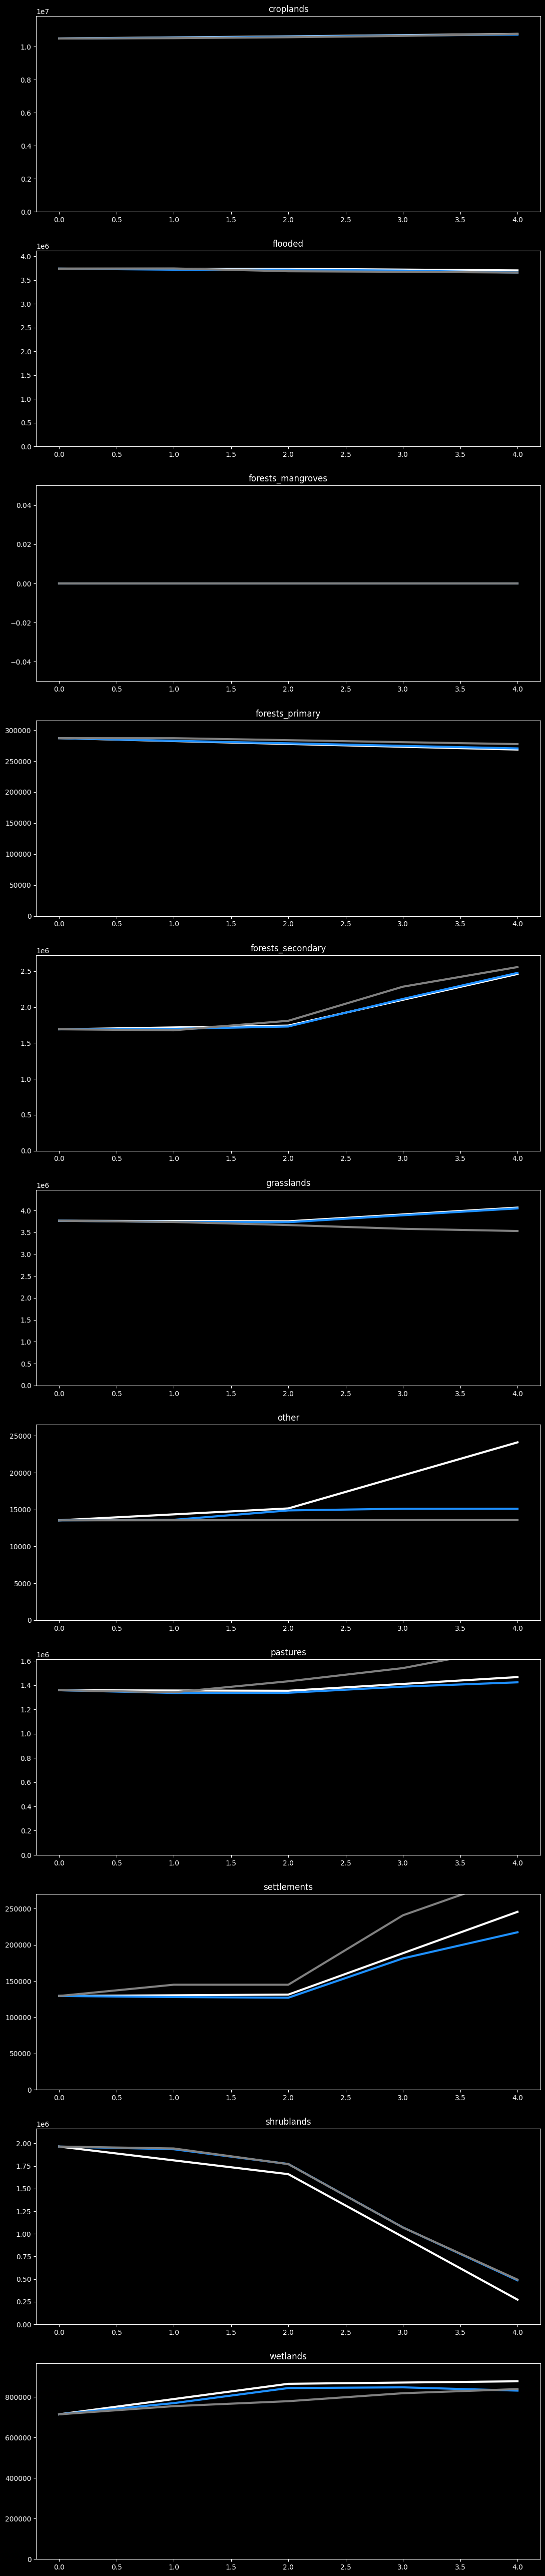

In [427]:
def plot_land_use_comparison(
    cat: str,
    df_areas: pd.DataFrame,
    df_out: pd.DataFrame,
    df_out_original: pd.DataFrame,
    ax: Union['plt.Axes', None] = None
) -> 'plt.Plot':

    ##  INITIALIZE
    
    fig = None
    field = _MODVAR_AREA_LNDU.build_fields(category_restrictions = cat, )

    if ax is None:
        fig, ax = plt.subplots(figsize = (13, 7))
        
        
    # build vectors for plotting
    vec_empirical = df_areas[field].to_numpy()*area
    vec_estimated = df_out[field].to_numpy()
    vec_original = df_out_orig[field].to_numpy()
    y_max = max(vec_empirical.max(), vec_estimated.max(), )*1.1
    
    # set range
    ax.set_ylim(0, y_max)
    ax.set_title(cat)

    # add to axis
    ax.plot(vec_empirical, label = "empirical", color = "white", linewidth = 3, )
    ax.plot(vec_estimated, label = "estimated", color = "dodgerblue", linewidth = 3, )
    ax.plot(vec_original, label = "original", color = "grey", linewidth = 3, )
    
    return fig 
    

fig, ax = plt.subplots(_ATTR_LNDU.n_key_values, 1, figsize = (13, 66))


for i, cat in enumerate(_ATTR_LNDU.key_values):
    plot = plot_land_use_comparison(
        cat,
        df_areas,
        df_out,
        df_out_orig,
        ax = ax[i],
    )

In [432]:
fig.savefig("/Users/usuario/Desktop/calib.png", dpi = 200)

# Use early years for transitions going forward
- Later years show high levels of instability between key classes (e.g., shrublands to secondary forests)


In [454]:

sf._concat_df(
    [
        df_transitions_adj,
        df_append[df_transitions_adj.columns]
    ]
)
df_append = (
    pd.DataFrame(
        df_transitions_adj
        .iloc[0:2]
        .drop(columns = [time_periods.field_year], )
        .mean(axis = 0)
    )
    .transpose()
)

df_append[time_periods.field_year] = df_transitions_adj[time_periods.field_year].max() + 1



df_transitions_estimated = sf._concat_df(
    [
        df_transitions_adj,
        df_append[df_transitions_adj.columns]
    ]
)

df_transitions_estimated = (
    pd.merge(
        _DF_YEARS,
        df_transitions_estimated,
        how = "left",
    )
    .bfill()
    .ffill()
)


# Export transitions

In [467]:
fn_export = cdn.file_name_from_variable(_MODVAR_LNDU_TRANSITION, )
df_transitions_estimated.to_csv(
    cdn._PATH_OUTPUTS.joinpath(fn_export, ),
    encoding = "UTF-8",
    index = None,
)

# Do some testing

In [460]:
df_test = sf.match_df_to_target_df(
    df_inputs,
    df_transitions_estimated,
    [
        time_periods.field_year,
    ]
)



<Axes: >

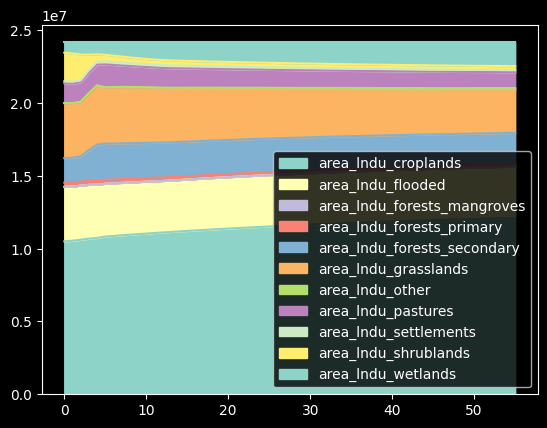

In [464]:
df_test_out = models.model_afolu(df_test)
(
    _MODVAR_AREA_LNDU
    .get_from_dataframe(df_test_out)
    .plot
    .area()
)

<Axes: >

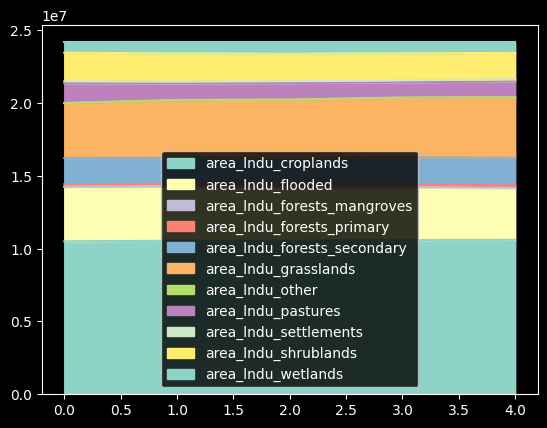